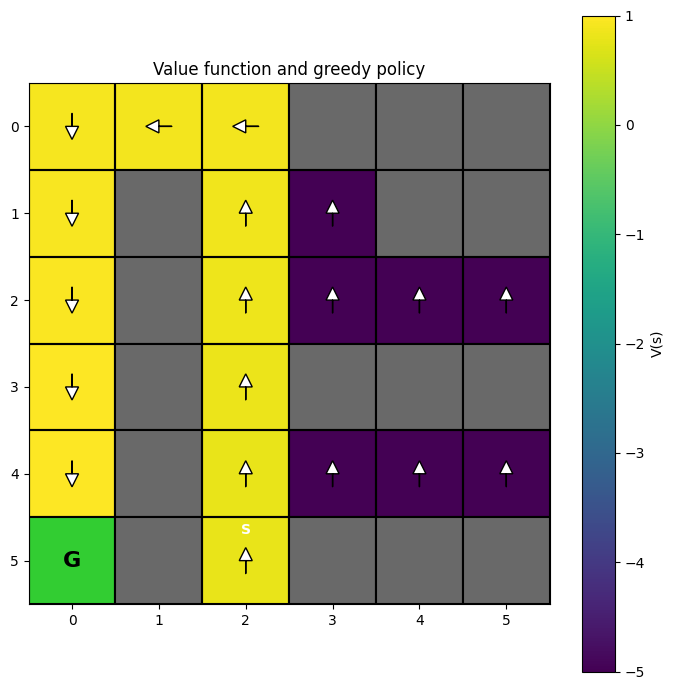

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum

MAZE = """
000BBB
0B00BB
0B0000
0B0BBB
0B0000
GBSBBB
"""

MAZE = np.array([list(line) for line in MAZE.splitlines() if line.strip()])

class Action(Enum):
    UP = 0
    DOWN = 1
    LEFT = 2
    RIGHT = 3
    
def apply_action(maze, state, action):
    if action == Action.UP.value:
        next_state = (state[0] - 1, state[1])
    elif action == Action.DOWN.value:
        next_state = (state[0] + 1, state[1])
    elif action == Action.LEFT.value:
        next_state = (state[0], state[1] - 1)
    elif action == Action.RIGHT.value:
        next_state = (state[0], state[1] + 1)

    if next_state[0] < 0 or next_state[0] >= maze.shape[0] or next_state[1] < 0 or next_state[1] >= maze.shape[1]:
        next_state = state
    elif maze[next_state] == 'B':
        next_state = state

    reward = -0.01
    done = False
    if maze[next_state] == 'G':
        reward = 1
        done = True
    
    return next_state, reward, done

DATA_STATES = [
    (5, 2), (4, 2), (3, 2), (2, 2), (1, 2), (0, 2),
    (0, 1), (0, 0), (1, 0), (2, 0), (3, 0), (4, 0),
]

# Convert data to (state, action, next_state, reward, done) tuples.
DATA = [    
    (s, a) + apply_action(MAZE, s, a)
    for s in DATA_STATES
    for a in range(4)
]

# =========================================================
# Training
# =========================================================

PESSIMISTIC_Q_TABLE = True
np.random.seed(1)
Q_init = (
    np.random.randn(*(MAZE.shape + (4,)))
    if not PESSIMISTIC_Q_TABLE
    else np.ones(MAZE.shape + (4,)) * -5
)
Q = Q_init.copy()

for i in range(100):
    for state, action, next_state, reward, done in DATA:
        Q[state][action] = reward + 0.99 * np.max(Q[next_state]) * (1 - done)


# ====================================================================================
# Visualization
# ====================================================================================

# Arrow direction (dx, dy) for each action in image coordinates (row = y, col = x).
# Note: in imshow, the y-axis points downward, so DOWN increases y.
ACTION_ARROWS = {
    Action.UP.value:    (0.0, -0.3),
    Action.DOWN.value:  (0.0,  0.3),
    Action.LEFT.value:  (-0.3, 0.0),
    Action.RIGHT.value: (0.3,  0.0),
}

V = np.max(Q, axis=-1)
greedy_policy = np.argmax(Q, axis=-1)

# Only show value/policy for traversable cells.
valid = (MAZE == '0') | (MAZE == 'S')
V_display = np.where(valid, V, np.nan)

rows, cols = MAZE.shape

fig, ax = plt.subplots(figsize=(cols + 1, rows + 1))
im = ax.imshow(V_display, cmap='viridis')
fig.colorbar(im, ax=ax, label='V(s)')

# Draw bordered cells and annotate walls / goal / pit / start.
for r in range(rows):
    for c in range(cols):
        cell = MAZE[r, c]
        if cell == 'B':
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       facecolor='dimgray'))
        elif cell == 'G':
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       facecolor='limegreen'))
            ax.text(c, r, 'G', ha='center', va='center',
                    color='black', fontsize=16, fontweight='bold')
        elif cell == 'S':
            ax.text(c, r - 0.35, 'S', ha='center', va='center',
                    color='white', fontsize=10, fontweight='bold')
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                   fill=False, edgecolor='black', linewidth=1.5))

# Draw arrows for the greedy policy in each traversable cell.
for r in range(rows):
    for c in range(cols):
        if not valid[r, c]:
            continue
        a = greedy_policy[r, c]
        dx, dy = ACTION_ARROWS[a]
        ax.arrow(c - dx / 2, r - dy / 2, dx, dy,
                 head_width=0.15, head_length=0.15,
                 fc='white', ec='black', length_includes_head=True)

ax.set_xticks(np.arange(cols))
ax.set_yticks(np.arange(rows))
ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
ax.tick_params(which='minor', length=0)
ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(rows - 0.5, -0.5)
ax.set_title('Value function and greedy policy')
plt.tight_layout()
plt.show()

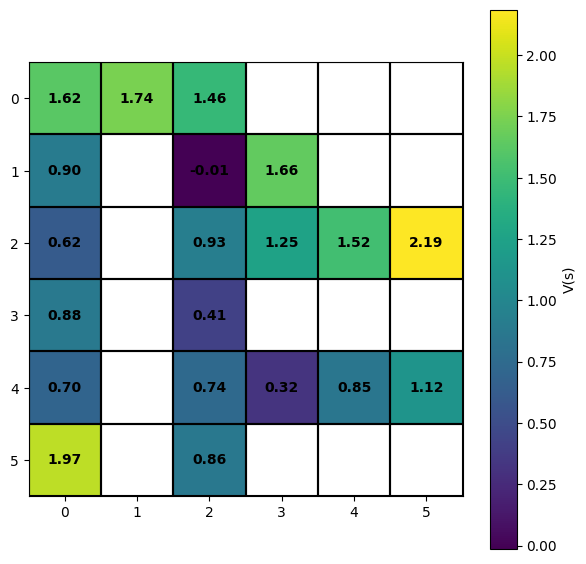

In [58]:
# ================================
# Plot initial Q values
# ================================

rows, cols = MAZE.shape

V_init = np.max(Q_init, axis=-1)
V_init[MAZE == 'B'] = np.nan
fig, ax = plt.subplots(figsize=(cols + 1, rows + 1))
im = ax.imshow(V_init, cmap='viridis')
fig.colorbar(im, ax=ax, label='V(s)')

# Draw bordered cells and annotate walls / goal / pit / start.
for r in range(rows):
    for c in range(cols):
        if MAZE[r, c] != 'B':
            ax.text(c, r, f"{V_init[r, c]:.2f}", ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                   fill=False, edgecolor='black', linewidth=1.5))
